In [1]:
import sys
sys.path.insert(0, "..")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from datetime import datetime
from collections import defaultdict

from preprocessing.graph_builder import HomogeneousGraphBuilder
from retrievers import DenseRetriever

PREPROCESSED_DIR = "../data/preprocessed_new"
PAR_TO_PAR_PATH = "../data/par-to-par-cleaned.csv"
CUTOFF_YEAR = 2018

/Users/christianjensen/Documents/Master-Thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load precomputed embeddings and metadata
preprocessed_path = Path(PREPROCESSED_DIR)

with open(preprocessed_path / "paragraph_metadata.pkl", "rb") as f:
    par_metadata = pickle.load(f)

with open(preprocessed_path / "citations.pkl", "rb") as f:
    citations = pickle.load(f)

doc_embeddings = np.load(preprocessed_path / "paragraph_embeddings_doc.npy")
query_embeddings = np.load(preprocessed_path / "paragraph_embeddings_query.npy")

# Create ID mappings
par_id_to_idx = {m["id"]: i for i, m in enumerate(par_metadata)}
idx_to_par_id = {i: m["id"] for i, m in enumerate(par_metadata)}

print(f"Loaded {len(par_metadata)} paragraphs")
print(f"Loaded {len(citations)} citation edges")
print(f"Document embeddings shape: {doc_embeddings.shape}")
print(f"Query embeddings shape: {query_embeddings.shape}")

Loaded 677050 paragraphs
Loaded 618010 citation edges
Document embeddings shape: (677050, 1024)
Query embeddings shape: (677050, 1024)


In [3]:
# Build queries and relevance map from citation pairs
# Load par-to-par data for query/relevance info
df = pd.read_csv(PAR_TO_PAR_PATH)
df["DATE_FROM"] = pd.to_datetime(df["DATE_FROM"], errors="coerce")
df["DATE_TO"] = pd.to_datetime(df["DATE_TO"], errors="coerce")

# Filter to test queries (citing paragraphs from >= cutoff year)
cutoff_date = pd.Timestamp(f"{CUTOFF_YEAR}-01-01")
test_df = df[df["DATE_FROM"] >= cutoff_date].copy()

# Create query IDs (FROM paragraph) and build relevance map
test_df["FROM_ID"] = "par:" + test_df["CELEX_FROM"].astype(str) + ":" + test_df["NUMBER_FROM"].astype(str)
test_df["TO_ID"] = "par:" + test_df["CELEX_TO"].astype(str) + ":" + test_df["NUMBER_TO"].astype(str)

# rel_map: query_id -> set of relevant doc_ids
rel_map: dict[str, set[str]] = defaultdict(set)
for _, row in test_df.iterrows():
    rel_map[row["FROM_ID"]].add(row["TO_ID"])

# Build unique queries
queries_df = test_df.drop_duplicates(subset=["FROM_ID"])[["FROM_ID", "CELEX_FROM", "NUMBER_FROM", "TEXT_FROM"]].copy()
queries_df = queries_df.rename(columns={"FROM_ID": "QID", "TEXT_FROM": "TEXT"})

print(f"Total test queries: {len(queries_df)}")
print(f"Total citation pairs: {len(test_df)}")
print(f"Unique cited paragraphs: {test_df['TO_ID'].nunique()}")

Total test queries: 11890
Total citation pairs: 19727
Unique cited paragraphs: 14793


In [4]:
# Build NetworkX graphs from citation data (training set only - before cutoff)
g_undirected = nx.Graph()
g_directed = nx.DiGraph()

# Get train paragraphs (before cutoff)
def parse_date(date_str: str | None) -> datetime | None:
    if not date_str:
        return None
    try:
        return datetime.fromisoformat(date_str)
    except:
        return None

train_par_ids = set()
for meta in par_metadata:
    date = parse_date(meta.get("date"))
    if date and date.year < CUTOFF_YEAR:
        train_par_ids.add(meta["id"])

# Add nodes (all train paragraphs)
for par_id in train_par_ids:
    g_undirected.add_node(par_id)
    g_directed.add_node(par_id)

# Add edges (only between train paragraphs)
edges_added = 0
for src_id, tgt_id in citations:
    if src_id in train_par_ids and tgt_id in train_par_ids:
        g_undirected.add_edge(src_id, tgt_id)
        g_directed.add_edge(src_id, tgt_id)
        edges_added += 1

print(f"Train paragraphs (nodes): {len(train_par_ids)}")
print(f"Citation edges: {edges_added}")
print(f"Graph nodes: {g_undirected.number_of_nodes()}")
print(f"Graph edges: {g_undirected.number_of_edges()}")

Train paragraphs (nodes): 505508
Citation edges: 90435
Graph nodes: 505508
Graph edges: 90419


In [5]:
# Initialize DenseRetriever with precomputed embeddings
retriever = DenseRetriever(preprocessed_dir=PREPROCESSED_DIR)

# Build index of train paragraphs for retrieval
train_indices = np.array([par_id_to_idx[pid] for pid in train_par_ids])
train_embeddings = doc_embeddings[train_indices]

retriever.create_index(train_embeddings.shape[1])
retriever.add_to_index(train_embeddings, train_indices)

# Get query embeddings for test queries
query_indices = []
valid_queries = []
for _, row in queries_df.iterrows():
    qid = row["QID"]
    if qid in par_id_to_idx:
        query_indices.append(par_id_to_idx[qid])
        valid_queries.append(qid)

query_embs = query_embeddings[query_indices]

# Perform retrieval
TOP_K = 50
retrieved_indices, scores = retriever.search_index(query_embs, TOP_K)

# Build ranked results: list of (query_id, [(doc_id, score), ...])
ranked_results: list[tuple[str, list[tuple[str, float]]]] = []
for i, qid in enumerate(valid_queries):
    docs = []
    for j in range(TOP_K):
        idx = retrieved_indices[i, j]
        if idx >= 0:
            doc_id = idx_to_par_id[idx]
            docs.append((doc_id, float(scores[i, j])))
    ranked_results.append((qid, docs))

print(f"Retrieved top-{TOP_K} for {len(ranked_results)} queries")

Loaded precomputed document embeddings: (677050, 1024)
Loaded precomputed query embeddings: (677050, 1024)
Loaded metadata for 677050 paragraphs
Retrieved top-50 for 11890 queries


In [6]:
# Compute distance from each retrieved doc to nearest relevant doc
def compute_distance_to_relevant_docs(
    ranked_results: list[tuple[str, list[tuple[str, float]]]],
    rel_map: dict[str, set[str]],
    graph: nx.Graph
) -> dict[str, list]:
    results = defaultdict(list)
    
    for query_id, docs in ranked_results:
        relevant_docs = rel_map.get(query_id, set())
        if not relevant_docs:
            continue
            
        for rank, (doc_id, score) in enumerate(docs):
            # Check if retrieved doc is already relevant
            if doc_id in relevant_docs:
                results['query_id'].append(query_id)
                results['retrieved_doc'].append(doc_id)
                results['rank'].append(rank + 1)
                results['distance'].append(0)
                results['nearest_relevant_doc'].append(doc_id)
                continue
            
            # Compute shortest path to any relevant doc
            min_distance = float('inf')
            nearest_doc = None
            
            if doc_id not in graph:
                results['query_id'].append(query_id)
                results['retrieved_doc'].append(doc_id)
                results['rank'].append(rank + 1)
                results['distance'].append(float('inf'))
                results['nearest_relevant_doc'].append(None)
                continue
            
            for rel_doc in relevant_docs:
                if rel_doc not in graph:
                    continue
                try:
                    distance = nx.shortest_path_length(graph, source=doc_id, target=rel_doc)
                    if distance < min_distance:
                        min_distance = distance
                        nearest_doc = rel_doc
                except nx.NetworkXNoPath:
                    continue
            
            results['query_id'].append(query_id)
            results['retrieved_doc'].append(doc_id)
            results['rank'].append(rank + 1)
            results['distance'].append(min_distance if min_distance != float('inf') else float('inf'))
            results['nearest_relevant_doc'].append(nearest_doc)
    
    return dict(results)

# Compute distances
distance_results = compute_distance_to_relevant_docs(
    ranked_results=ranked_results,
    rel_map=rel_map,
    graph=g_undirected
)

distance_df = pd.DataFrame(distance_results)
print(f"Computed distances for {len(distance_df)} retrieved documents")

Computed distances for 594500 retrieved documents


,total_retrieved_docs,docs_with_finite_distance,direct_hits,docs_with_infinite_distance,mean_distance,median_distance,min_distance,max_distance,p25_distance,p75_distance,p90_distance
0,594500,123139,11685,459676,5.550768,4.0,1.0,53.0,2.0,6.0,12.0


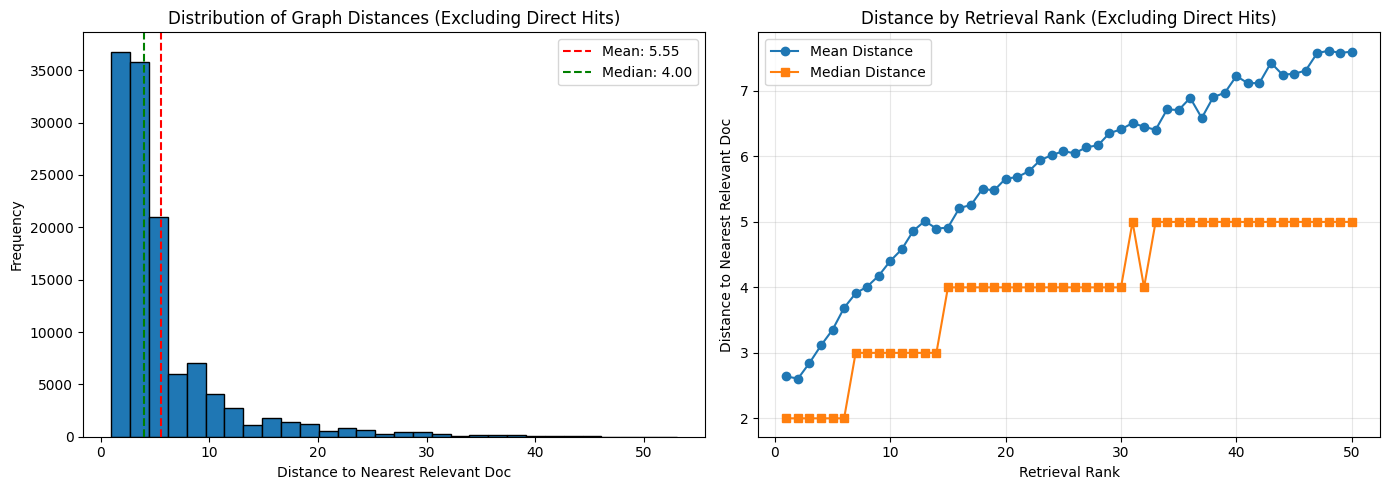

In [7]:
# Summary statistics for distances
finite_distances = distance_df[(distance_df['distance'] != float('inf')) & (distance_df['distance'] > 0)]['distance']
infinite_count = (distance_df['distance'] == float('inf')).sum()
direct_hits_count = (distance_df['distance'] == 0).sum()

summary_stats = {
    'total_retrieved_docs': len(distance_df),
    'docs_with_finite_distance': len(finite_distances),
    'direct_hits': direct_hits_count,
    'docs_with_infinite_distance': infinite_count,
    'mean_distance': finite_distances.mean() if len(finite_distances) > 0 else np.nan,
    'median_distance': finite_distances.median() if len(finite_distances) > 0 else np.nan,
    'min_distance': finite_distances.min() if len(finite_distances) > 0 else np.nan,
    'max_distance': finite_distances.max() if len(finite_distances) > 0 else np.nan,
    'p25_distance': finite_distances.quantile(0.25) if len(finite_distances) > 0 else np.nan,
    'p75_distance': finite_distances.quantile(0.75) if len(finite_distances) > 0 else np.nan,
    'p90_distance': finite_distances.quantile(0.90) if len(finite_distances) > 0 else np.nan,
}

summary_stats_df = pd.DataFrame([summary_stats])
display(summary_stats_df)

# Plot distribution of distances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of distances (excluding infinite and direct hits)
if len(finite_distances) > 0:
    axes[0].hist(finite_distances, bins=30, edgecolor='black')
    axes[0].set_xlabel('Distance to Nearest Relevant Doc')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Graph Distances (Excluding Direct Hits)')
    axes[0].axvline(finite_distances.mean(), color='red', linestyle='--', label=f'Mean: {finite_distances.mean():.2f}')
    axes[0].axvline(finite_distances.median(), color='green', linestyle='--', label=f'Median: {finite_distances.median():.2f}')
    axes[0].legend()

# Distance by rank (excluding direct hits)
rank_distance = distance_df[(distance_df['distance'] != float('inf')) & (distance_df['distance'] > 0)].groupby('rank')['distance'].agg(['mean', 'median', 'count'])
if len(rank_distance) > 0:
    axes[1].plot(rank_distance.index, rank_distance['mean'], marker='o', label='Mean Distance')
    axes[1].plot(rank_distance.index, rank_distance['median'], marker='s', label='Median Distance')
    axes[1].set_xlabel('Retrieval Rank')
    axes[1].set_ylabel('Distance to Nearest Relevant Doc')
    axes[1].set_title('Distance by Retrieval Rank (Excluding Direct Hits)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
# Classify relationship of retrieved docs to relevant docs using directed graph
def classify_relationship_to_relevant(
    doc_id: str,
    relevant_docs: set[str],
    graph: nx.DiGraph,
    graph_reversed: nx.DiGraph,
    max_depth: int = 6,
) -> str:
    """Classify relationship: exact > parent > child > sibling > ancestor > descendant > unrelated > not_in_graph"""
    if doc_id not in graph:
        return "not_in_graph"

    rel_in_graph = {r for r in relevant_docs if r in graph}
    if not rel_in_graph:
        return "unrelated"

    if doc_id in rel_in_graph:
        return "exact"

    # parent / child (direct)
    for r in rel_in_graph:
        if graph.has_edge(doc_id, r):
            return "parent"
        if graph.has_edge(r, doc_id):
            return "child"

    # sibling (shared parent)
    parents = set(graph.predecessors(doc_id))
    if parents:
        for p in parents:
            children_p = set(graph.successors(p))
            if rel_in_graph & children_p:
                return "sibling"

    # ancestor / descendant
    forward_lengths = nx.single_source_shortest_path_length(graph, doc_id, cutoff=max_depth)
    for r in rel_in_graph:
        d = forward_lengths.get(r)
        if d is not None and d >= 2:
            return "ancestor"

    backward_lengths = nx.single_source_shortest_path_length(graph_reversed, doc_id, cutoff=max_depth)
    for r in rel_in_graph:
        d = backward_lengths.get(r)
        if d is not None and d >= 2:
            return "descendant"

    return "unrelated"


Gd_rev = g_directed.reverse(copy=False)

records = []
for qid, group in distance_df.groupby("query_id"):
    rel_set = set(rel_map.get(qid, set()))
    if not rel_set:
        continue
    for row in group.itertuples():
        doc_id = row.retrieved_doc
        dval = getattr(row, "distance", None)
        max_d = 15 if (dval is None or dval != float("inf")) else 0
        label = classify_relationship_to_relevant(
            doc_id=doc_id,
            relevant_docs=rel_set,
            graph=g_directed,
            graph_reversed=Gd_rev,
            max_depth=max_d,
        )
        records.append({
            "query_id": qid,
            "retrieved_doc": doc_id,
            "rank": int(row.rank),
            "relationship": label,
        })

relationship_df = pd.DataFrame.from_records(records)

# Display counts
counts = relationship_df["relationship"].value_counts(dropna=False)
summary = counts.rename_axis("relationship").reset_index(name="count")
summary["percentage"] = 100.0 * summary["count"] / float(len(relationship_df))

# Near-misses distribution
merged = relationship_df.merge(
    distance_df[["query_id", "retrieved_doc", "distance"]],
    on=["query_id", "retrieved_doc"],
    how="left",
)
near = merged[(merged["distance"] != float("inf")) & (merged["distance"] > 0)]
counts_near = near["relationship"].value_counts(dropna=False)
summary_near = counts_near.rename_axis("relationship").reset_index(name="count")
summary_near["percentage"] = 100.0 * summary_near["count"] / float(len(near)) if len(near) > 0 else 0

print("=== Overall Relationship Distribution ===")
display(summary.sort_values("count", ascending=False).reset_index(drop=True).round({"percentage": 2}))
print("\n=== Near-Miss Relationship Distribution ===")
display(summary_near.sort_values("count", ascending=False).reset_index(drop=True).round({"percentage": 2}))

=== Overall Relationship Distribution ===


,relationship,count,percentage
0,unrelated,551405,92.75
1,exact,11685,1.97
2,parent,8994,1.51
3,child,7175,1.21
4,descendant,6736,1.13
5,ancestor,5793,0.97
6,sibling,2712,0.46



=== Near-Miss Relationship Distribution ===


,relationship,count,percentage
0,unrelated,91729,74.49
1,parent,8994,7.30
2,child,7175,5.83
3,descendant,6736,5.47
4,ancestor,5793,4.70
5,sibling,2712,2.20


In [9]:
# Expanded retrieval metrics: expand top-k retrieved docs by N hops in the graph
from typing import Iterable

def expand_from_seeds(seeds: set[str], graph: nx.Graph, hops: int) -> set[str]:
    visited = set(seeds)
    frontier = set(seeds)
    for _ in range(int(hops)):
        if not frontier:
            break
        neighbors = set()
        for u in frontier:
            if u in graph:
                neighbors.update(graph.neighbors(u))
        frontier = neighbors - visited
        visited |= frontier
    return visited


def compute_expanded_retrieval_metrics(
    *,
    distance_df: pd.DataFrame,
    rel_map: dict[str, set[str]],
    graph: nx.Graph,
    k_values: Iterable[int] = (1, 3, 5, 10, 20, 50),
    hop_values: Iterable[int] = (0, 1, 2, 3, 5, 10),
) -> pd.DataFrame:
    eval_df = distance_df[["query_id", "retrieved_doc", "rank"]].copy()
    valid_qids = [qid for qid in eval_df["query_id"].unique() if len(rel_map.get(qid, set())) > 0]
    eval_df = eval_df[eval_df["query_id"].isin(valid_qids)].copy()
    eval_df = eval_df.sort_values(["query_id", "rank"])

    rows = []
    for hops in hop_values:
        grouped = eval_df.groupby("query_id", sort=False)
        for k in k_values:
            precisions, recalls, n_expanded = [], [], []
            for qid, qdf in grouped:
                rel_set = rel_map.get(qid, set())
                if not rel_set:
                    continue
                seeds = set(qdf.head(int(k))["retrieved_doc"].astype(str).tolist())
                if not seeds:
                    continue
                expanded = expand_from_seeds(seeds, graph, int(hops))
                if not expanded:
                    continue
                hits = len(expanded & rel_set)
                precisions.append(hits / float(len(expanded)))
                recalls.append(hits / float(len(rel_set)) if len(rel_set) > 0 else 0.0)
                n_expanded.append(len(expanded))
            
            precision = float(np.mean(precisions)) if precisions else 0.0
            recall = float(np.mean(recalls)) if recalls else 0.0
            f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
            rows.append({
                "k": int(k),
                "hops": int(hops),
                "precision_expanded": precision,
                "recall_expanded": recall,
                "f1_expanded": f1,
                "mean_expanded": float(np.mean(n_expanded)) if n_expanded else 0.0,
            })
    return pd.DataFrame(rows).sort_values(["hops", "k"]).reset_index(drop=True)


# Compute expanded metrics
k_grid = [1, 3, 5, 10, 20, 50]
hop_grid = [0, 1, 2, 3, 5, 10]
expanded_metrics_df = compute_expanded_retrieval_metrics(
    distance_df=distance_df,
    rel_map=rel_map,
    graph=g_undirected,
    k_values=k_grid,
    hop_values=hop_grid,
)

print("=== Expanded Retrieval Metrics ===")
print(expanded_metrics_df.round(4))

=== Expanded Retrieval Metrics ===
     k  hops  precision_expanded  recall_expanded  f1_expanded  mean_expanded
0    1     0              0.3814           0.2964       0.3336         1.0000
1    3     0              0.1975           0.4254       0.2698         3.0000
2    5     0              0.1370           0.4767       0.2128         5.0000
3   10     0              0.0792           0.5330       0.1380        10.0000
4   20     0              0.0440           0.5769       0.0818        20.0000
5   50     0              0.0197           0.6264       0.0381        50.0000
6    1     1              0.2789           0.3914       0.3257         2.5581
7    3     1              0.1460           0.5017       0.2262         6.1439
8    5     1              0.1017           0.5411       0.1712         9.3902
9   10     1              0.0591           0.5859       0.1074        17.1758
10  20     1              0.0332           0.6162       0.0630        31.7589
11  50     1              0.0

In [10]:
# Summary statistics
print("=" * 60)
print("GRAPH ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nData Statistics:")
print(f"  Total paragraphs: {len(par_metadata)}")
print(f"  Train paragraphs (< {CUTOFF_YEAR}): {len(train_par_ids)}")
print(f"  Citation edges in train: {edges_added}")

print(f"\nRetrieval Statistics:")
print(f"  Test queries: {len(valid_queries)}")
print(f"  Total retrieved docs: {len(distance_df)}")
print(f"  Direct hits (distance=0): {direct_hits_count} ({100*direct_hits_count/len(distance_df):.2f}%)")
print(f"  Infinite distance: {infinite_count} ({100*infinite_count/len(distance_df):.2f}%)")
print(f"  Near misses: {len(finite_distances)} ({100*len(finite_distances)/len(distance_df):.2f}%)")

if len(finite_distances) > 0:
    print(f"\nDistance Statistics (Near Misses):")
    print(f"  Mean: {finite_distances.mean():.2f}")
    print(f"  Median: {finite_distances.median():.2f}")
    print(f"  25th/75th percentile: {finite_distances.quantile(0.25):.2f} / {finite_distances.quantile(0.75):.2f}")


GRAPH ANALYSIS SUMMARY

Data Statistics:
  Total paragraphs: 677050
  Train paragraphs (< 2018): 505508
  Citation edges in train: 90435

Retrieval Statistics:
  Test queries: 11890
  Total retrieved docs: 594500
  Direct hits (distance=0): 11685 (1.97%)
  Infinite distance: 459676 (77.32%)
  Near misses: 123139 (20.71%)

Distance Statistics (Near Misses):
  Mean: 5.55
  Median: 4.00
  25th/75th percentile: 2.00 / 6.00
